<a href="https://colab.research.google.com/github/Nermeen-Moussa/ML-DL-Reference-Guide/blob/machine-learning/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error


**Data Creation**

In [3]:
data = []

for _ in range(500):
    team_name = f"Team {chr(random.randint(65, 90))}"
    season = random.randint(2010, 2022)
    wins = random.randint(50, 110)
    losses = 162 - wins
    hits = random.randint(1200, 1600)
    doubles = random.randint(200, 350)
    triples = random.randint(10, 40)
    home_runs = random.randint(100, 250)
    strikeouts = random.randint(1000, 1500)

    hits_adjusted = hits + (wins - 80) * 5
    doubles_adjusted = doubles + (wins - 80) * 2
    triples_adjusted = triples + (wins - 80)
    home_runs_adjusted = home_runs + (wins - 80) * 3
    strikeouts_adjusted = strikeouts - (wins - 80) * 10

    data.append([team_name, season, wins, losses, hits_adjusted, doubles_adjusted, triples_adjusted, home_runs_adjusted, strikeouts_adjusted])

columns = ["Team", "Season", "Wins", "Losses", "Hits", "Doubles", "Triples", "HomeRuns", "Strikeouts"]

df = pd.DataFrame(data, columns=columns)
df.head()

,Team,Season,Wins,Losses,Hits,Doubles,Triples,HomeRuns,Strikeouts
0,Team K,2012,54,108,1457,150,2,164,1544
1,Team M,2021,110,52,1482,297,48,208,877
2,Team M,2011,85,77,1494,354,19,218,1259
3,Team S,2017,86,76,1239,290,38,131,1431
4,Team P,2017,110,52,1534,277,55,327,1159


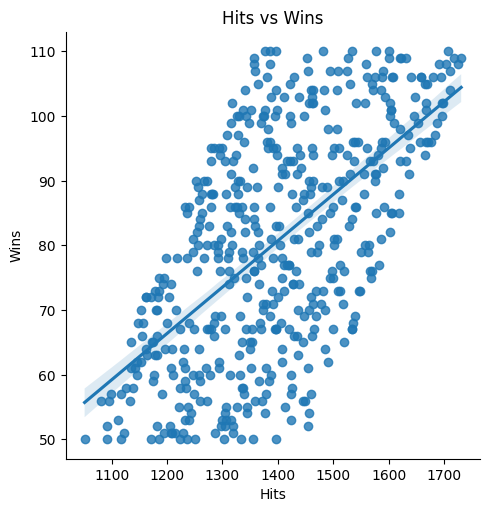

In [4]:
sns.lmplot(x="Hits", y="Wins", data=df)
plt.title("Hits vs Wins")
plt.show()

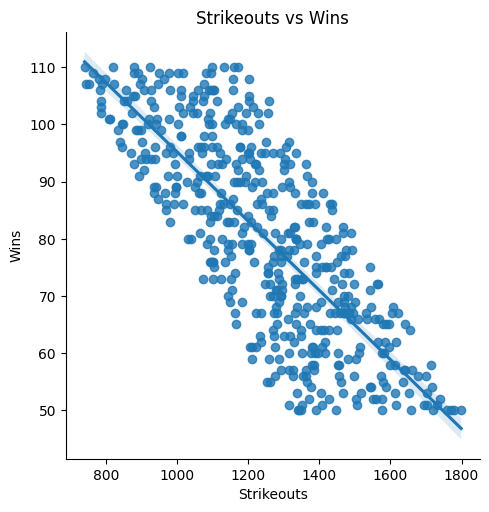

In [5]:
sns.lmplot(x="Strikeouts", y="Wins", data=df)
plt.title("Strikeouts vs Wins")
plt.show()


In [6]:
df2=df.drop(columns=['Losses','Season','Team'],axis=1)
df2.head()


,Wins,Hits,Doubles,Triples,HomeRuns,Strikeouts
0,54,1457,150,2,164,1544
1,110,1482,297,48,208,877
2,85,1494,354,19,218,1259
3,86,1239,290,38,131,1431
4,110,1534,277,55,327,1159


In [7]:
df2.columns

Index(['Wins', 'Hits', 'Doubles', 'Triples', 'HomeRuns', 'Strikeouts'], dtype='object')

In [8]:
X=df[['Hits', 'Doubles', 'Triples', 'HomeRuns', 'Strikeouts']]
y=df['Wins']


In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
lr=LinearRegression()
lr.fit(X_train,y_train)
lr.score(X_train,y_train)
lr.score(X_test,y_test)

0.885962678822689

In [12]:
y_pred=lr.predict(X_test)
print('mean_absolute_error',mean_absolute_error(y_test,y_pred))
print('mean_squared_error',mean_squared_error(y_test,y_pred))
print('root_mean_squared_error',np.sqrt(mean_squared_error(y_test,y_pred)))



mean_absolute_error 5.120925379860939
mean_squared_error 40.050944937094364
root_mean_squared_error 6.32858158966876


In [14]:
r2_score(y_test,y_pred)
print(lr.coef_)
print(lr.intercept_)

[ 0.01359722  0.03088922  0.42777233  0.04847971 -0.0177902 ]
55.55054655097879
